# 9. Counting statistics of a disordered eight-site chain and the quantum-jump benchmark — Fig. 10 (Sec. VII, SM)

Eight Kerr cavities in an open chain, $\Delta_j=-\kappa+0.3\kappa\,\xi_j$ (one disorder realization, listed in the SM), $J=0.4\kappa$; the drive $\eta=\kappa$ acts on site 0 only, which is also the counted site. The tilted Liouvillian cannot be diagonalized directly. The diagrams (full recursion, six orders, truncated at $N^*=6$ with band $\pm\delta$) and the Gaussian tilted-Riccati baseline are compared with waiting-time Monte Carlo wave-function trajectories at $U=0.04$, $0.08$, $0.1\kappa$ (1216, 3072, 3552 trajectories; Fock cutoffs set by the convergence of $c_3/c_1$ itself; two-window estimator with bootstrap errors).

**Part A** runs the diagrammatic cumulants of the chain here (third order, finite differences; minutes). **Part B** regenerates Fig. 10 from the stored diagram, Gaussian, and trajectory estimates and prints the numbers of Sec. VII and of the SM section. Recomputing the raw inputs: `diag_fcs_contour_rs.py` and `gauss_chain_root.py` (minutes); the trajectories with `prod_gpu.py` (cupy, ~2 GPU-days) followed by `traj_fcs_estimator.py` on the jump records (Zenodo data archive, unpacked to `trajectories/runs/`) — `regenerate_traj_fcs.sh` chains them.

In [1]:
from common import *
FAST = True      # True: reduced orders and cutoffs, minutes.  False: the orders and cutoffs of the paper (see the runtime note)
print("repository:", os.path.basename(CODE), "| FAST =", FAST, "| paper sources:", "found" if PAPER else "not present (Tables V and SI from notebooks/paper_reference/)")

repository: gh_staging | FAST = True | paper sources: not present (Tables V and SI from notebooks/paper_reference/)


## Part A — the calculation: diagrammatic counting cumulants of the chain

detunings: [-1.039031 -0.715488 -0.761393 -0.793461 -1.064557 -1.004186 -0.893986
 -1.263518]
U=0.0: c1 0.80911  Fano 0.99979  c3/c1 1.00021   (third order, finite differences)


U=0.04: c1 0.85004  Fano 1.05887  c3/c1 1.19225   (third order, finite differences)


U=0.08: c1 0.89990  Fano 1.14875  c3/c1 1.52272   (third order, finite differences)


U=0.1: c1 0.92887  Fano 1.20729  c3/c1 1.75237   (third order, finite differences)


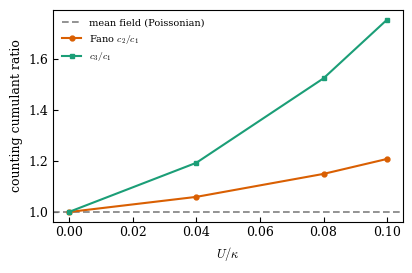

In [2]:
from fcs_multi import TiltedChain, cumulants as cum_multi
rngf=np.random.default_rng(5); [rngf.uniform(-1,1,k) for k in (2,4,6)]      # the disorder realization of the paper (parameters.json)
Kf=8; detf=-1.0+0.3*rngf.uniform(-1,1,Kf); etaf=np.zeros(Kf); etaf[0]=1.0
print("detunings:", np.round(detf, 6))
Us_f=[0.0,0.04,0.08,0.10] if FAST else [0.0,0.02,0.04,0.06,0.08,0.10]
fano,c3r=[],[]
for U in Us_f:
    def bf(chi,U=U):
        ch=TiltedChain(Kf,1.0,detf,0.4,etaf,U,ring=False); ch.set_tilt(0,chi,1.0); return ch
    c=cum_multi(bf,None,3 if U>0 else 0,5 if U>0 else 2,h=0.05)
    fano.append(c[1]); c3r.append(c[2]); print(f"U={U}: c1 {c[0]:.5f}  Fano {c[1]:.5f}  c3/c1 {c[2]:.5f}   (third order, finite differences)")
fig,ax=plt.subplots(figsize=(4.2,2.8))
ax.axhline(1.0,color='0.5',ls=(0,(4,2)),lw=1.2,label='mean field (Poissonian)')
ax.plot(Us_f,fano,'o-',color=COL[0],ms=3.5,label=r'Fano $c_2/c_1$')
ax.plot(Us_f,c3r,'s-',color=COL[1],ms=3.5,label=r'$c_3/c_1$')
ax.set_xlabel('$U/\\kappa$'); ax.set_ylabel('counting cumulant ratio'); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()

## Part B — Fig. 10 of the paper, the trajectory benchmark, and the numbers of Sec. VII

$ (cd code/benchmarks/trajectories; python3 traj_fcs_final.py)   [1.7 s, exit 0]
{"0.04": [0.8507, 1.0635, 1.2855, 0.0009, 0.0071, 0.0577], "0.08": [0.9009, 1.1541, 1.585, 0.0006, 0.0049, 0.0446], "0.10": [0.9309, 1.2363, 2.0536, 0.0006, 0.0049, 0.0491], "0.10_cut8": [0.9283, 1.2098, 1.7423, 0.001, 0.0084, 0.0846]}


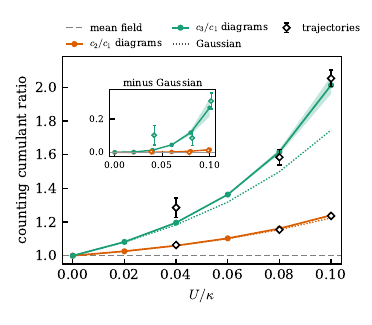

In [3]:
run("python3 traj_fcs_final.py", "benchmarks/trajectories", timeout=600)
paper_figure("benchmarks/trajectories/fig_fcs.pdf")

In [4]:
T = J("benchmarks", "truncation", "truncation_results.json")["chain8"]["results"]
key = lambda U: [k for k in T if abs(T[k]["U"]-U) < 1e-9][0]
d = lambda U, q: T[key(U)]["fullRS"][q]; g = lambda U: T[key(U)]["gaussian"]["value"]
print("Sec. VII, diagrams versus the Gaussian theory")
quoted("U=0.1: deviation from Poisson, Fano / c3/c1 (%)", "24 / 101", f"{100*(d(0.1,'fano')['value']-1):.0f} / {100*(d(0.1,'c3c1')['value']-1):.0f}")
quoted("U=0.1: Gaussian share of the deviation, Fano / c3/c1 (%)", "93 / 74", f"{100*(g(0.1)[1]-1)/(d(0.1,'fano')['value']-1):.0f} / {100*(g(0.1)[2]-1)/(d(0.1,'c3c1')['value']-1):.0f}")
quoted("diagrams minus Gaussian on c3/c1, U=0.02 -> 0.1", "0.002 -> 0.27", f"{d(0.02,'c3c1')['value']-g(0.02)[2]:.3f} -> {d(0.1,'c3c1')['value']-g(0.1)[2]:.2f}")
rat = [(d(U,'c3c1')['value']-g(U)[2])/(d(U,'fano')['value']-g(U)[1]) for U in (0.02,0.04,0.06,0.08,0.1)]
quoted("ratio to the difference on the Fano factor (17 to 'forty')", "17-40", f"{min(rat):.0f}-{max(rat):.0f}")
quoted("delta at U=0.08: Fano / c3/c1", "0.0012 / 0.014", f"{d(0.08,'fano')['delta']:.4f} / {d(0.08,'c3c1')['delta']:.3f}")
quoted("delta at U=0.10: Fano / c3/c1", "0.0045 / 0.053", f"{d(0.1,'fano')['delta']:.4f} / {d(0.1,'c3c1')['delta']:.3f}")
inc = d(0.1,'c3c1')['differences']; quoted("U=0.1: c3/c1 increments shrink per order by", 0.65, inc[-1]/inc[-2], "{:.2f}")
print("\nquantum-jump trajectories (SM section; z = (trajectory - reference)/s.e.)")
R = J("benchmarks", "trajectories", "traj_fcs_results.json")["results"]
print(" U     trajectories c1, c2/c1, c3/c1 (s.e.)                diagrams N<=6           Gaussian             z(diagrams)         z(Gaussian)")
for U in ("0.04","0.08","0.10"):
    dd = R[U]; e, s = dd["estimate"], dd["se"]; rf = dd["comparison"]["references"]
    print(f" {U}  {e[0]:.4f}({s[0]:.4f}) {e[1]:.4f}({s[1]:.4f}) {e[2]:.3f}({s[2]:.3f})   " + " ".join(f"{v:.4f}" for v in rf["diagrams_N6"]["value"]) + "   " +
          " ".join(f"{v:.4f}" for v in rf["gaussian"]["value"]) + "   " + " ".join(f"{z:5.2f}" for z in rf["diagrams_N6"]["z"]) + "   " + " ".join(f"{z:5.2f}" for z in rf["gaussian"]["z"]) +
          f"   [{dd['ntraj']} traj., T={dd['total_time']/1e6:.2f}e6/kappa, cutoffs {dd['cut']}]")
rf = R["0.10"]["comparison"]["references"]
quoted("U=0.1: third order c1, c2/c1, c3/c1", "0.9282, 1.2075, 1.749", ", ".join(f"{v:.4f}" for v in rf["diagrams_N3"]["value"]))
quoted("U=0.1: third order low by (s.e.)", "4.6, 5.8, 6.2", ", ".join(f"{z:.1f}" for z in rf["diagrams_N3"]["z"]))
quoted("U=0.1: Gaussian low by on Fano / c3/c1 (s.e.)", "2.5 / 6.3", f"{rf['gaussian']['z'][1]:.1f} / {rf['gaussian']['z'][2]:.1f}")
quoted("U=0.1: non-Gaussian part of c3/c1, trajectories / diagrams", "0.31 / 0.27", f"{R['0.10']['estimate'][2]-rf['gaussian']['value'][2]:.2f} / {rf['diagrams_N6']['value'][2]-rf['gaussian']['value'][2]:.2f}")
for U in ("0.04","0.08","0.10"):
    c = R[U]["c1_check"]; print(f"  U={U}: counted c1 {c['c1_counts']:.4f} vs kappa<n0> {c['occupation']:.4f}, |z| = {abs(c['z_martingale']):.1f} martingale s.e.")
c8 = R["0.10_cut8"]; e = R["0.10"]["estimate"]
quoted("run with cutoff 8 on site 0 (1024 traj.): c1, c2/c1, c3/c1", "0.9283(10), 1.2098(84), 1.742(85)", f"{c8['estimate'][0]:.4f}({c8['se'][0]:.4f}), {c8['estimate'][1]:.4f}({c8['se'][1]:.4f}), {c8['estimate'][2]:.3f}({c8['se'][2]:.3f})")
quoted("   low by (in its own s.e.)", "2.6, 3.2, 3.7", ", ".join(f"{(e[i]-c8['estimate'][i])/c8['se'][i]:.1f}" for i in range(3)))
V = J("benchmarks", "trajectories", "traj_validation.json")["results"]
print("\nvalidation of the estimator against exact long-time cumulants at the same cutoff (paper: all fifteen within 1.6 s.e.):")
for k, v in V.items(): print(f"   {k:18s} z = " + ", ".join(f"{z:5.2f}" for z in v["z"]) + f"   ({v['ntraj']} trajectories)")

Sec. VII, diagrams versus the Gaussian theory
  U=0.1: deviation from Poisson, Fano / c3/c1 (%)                paper     24 / 101   code     24 / 101
  U=0.1: Gaussian share of the deviation, Fano / c3/c1 (%)       paper      93 / 74   code      93 / 74
  diagrams minus Gaussian on c3/c1, U=0.02 -> 0.1                paper 0.002 -> 0.27   code 0.002 -> 0.27
  ratio to the difference on the Fano factor (17 to 'forty')     paper        17-40   code        17-38
  delta at U=0.08: Fano / c3/c1                                  paper 0.0012 / 0.014   code 0.0012 / 0.014
  delta at U=0.10: Fano / c3/c1                                  paper 0.0045 / 0.053   code 0.0045 / 0.053
  U=0.1: c3/c1 increments shrink per order by                    paper         0.65   code         0.63

quantum-jump trajectories (SM section; z = (trajectory - reference)/s.e.)
 U     trajectories c1, c2/c1, c3/c1 (s.e.)                diagrams N<=6           Gaussian             z(diagrams)         z(Gaussian)
 0.04